# Laboratorio · Señales (Fase 2)

Banco de pruebas de `src/tesis/senales/` — para **ver lo que el agente observa** cada
mes, sin las etiquetas. Corre el simulador, pasa cada lote por `MonitorSenales`, y
muestra los `ReporteSenales` en tabla, en detalle y en gráficos.

Kernel: **Python (tesis-pr196)**.

## 0. Setup

In [1]:
import sys
from pathlib import Path
def _raiz(inicio: Path) -> Path:
    for d in [inicio, *inicio.parents]:
        if (d / 'src' / 'tesis' / 'modelo_base.py').exists():
            return d
    raise RuntimeError('no encuentro la raíz')
ROOT = _raiz(Path.cwd())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from dataclasses import asdict

from tesis.simulador.poblacion import cargar_poblacion, COHORTE_OOT
from tesis.simulador.simulador import Simulador, ConfigSimulacion, plan_sano, agregar_episodio
from tesis.modelo_base import ModeloBase
from tesis.senales.monitor import MonitorSenales, Referencia
print('ROOT =', ROOT)

ROOT = /Users/duck/Documents/Maestría/TESIS


## 1. Modelo, pool y referencia
La **referencia** (el 'normal' contra el que se mide el drift) se construye desde
**train/DEV**, como en el monitoreo de scorecards.

In [2]:
info = pd.read_pickle(ROOT / 'data' / 'buro' / 'InfoModelamiento.pkl')
mb = ModeloBase.cargar(ROOT / 'models' / 'modelo_base.pkl')
dev = info[info['FECHA_CORTE'].isin(pd.to_datetime(mb.metadata['cohortes_dev'])) & info['VarDep'].isin([0, 1])]
pool = cargar_poblacion(ruta=ROOT / 'data' / 'buro' / 'InfoModelamiento.pkl', cohorte=COHORTE_OOT)
ref = Referencia.construir(dev, mb)
print('dev (referencia):', dev.shape[0], '| pool (ejecución):', pool.shape[0])

dev (referencia): 31696 | pool (ejecución): 9697


## 2. Plan de deterioro  ← *edita aquí*

In [3]:
cfg = ConfigSimulacion(n_periodos=24, tam_lote=2000, retardo_periodos=12,
                       fecha_inicio='2022-10-31', semilla=42)
plan = plan_sano(cfg.n_periodos)
agregar_episodio(plan, 'covariate_shift', inicio=5,  fin=9,  intensidad=0.9, forma='escalon')
agregar_episodio(plan, 'concept_drift',   inicio=13, fin=19, intensidad=1.0, forma='rampa')
[(i, e.tipo, e.intensidad) for i, e in enumerate(plan) if e.tipo != 'sano']

[(5, 'covariate_shift', 0.9),
 (6, 'covariate_shift', 0.9),
 (7, 'covariate_shift', 0.9),
 (8, 'covariate_shift', 0.9),
 (13, 'concept_drift', 0.1667),
 (14, 'concept_drift', 0.3333),
 (15, 'concept_drift', 0.5),
 (16, 'concept_drift', 0.6667),
 (17, 'concept_drift', 0.8333),
 (18, 'concept_drift', 1.0)]

## 3. Correr el monitor y ver la TABLA de señales
Cada fila = un mes. Estas columnas son, literalmente, lo que el agente verá para decidir.

In [9]:
mon = MonitorSenales(ref)
for lote in Simulador(pool, cfg, plan).stream():
    mon.observar(lote, mb)

h = mon.historia()
h['tipo'] = [e.tipo for e in plan]
cols = ['periodo','fecha', 'tipo', 'psi_score', 'psi_score_vs_previo', 'psi_feat_max',
        'score_medio', 'confianza_media', 'frac_incierto', 'etiquetas_disponibles', 'auc_revelado']
h[cols].round(3)

/var/folders/v6/d_4300n96432y2g47c2hlw640000gn/T/ipykernel_4536/2181456821.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  h[cols].round(3)


,periodo,fecha,tipo,psi_score,psi_score_vs_previo,psi_feat_max,score_medio,confianza_media,frac_incierto,etiquetas_disponibles,auc_revelado
0,0,2022-10-31,sano,0.016,NaN,0.018,0.424,0.648,0.040,False,NaN
1,1,2022-11-30,sano,0.028,0.012,0.017,0.427,0.650,0.038,False,NaN
2,2,2022-12-31,sano,0.016,0.010,0.030,0.415,0.658,0.041,False,NaN
3,3,2023-01-31,sano,0.035,0.010,0.022,0.431,0.649,0.036,False,NaN
4,4,2023-02-28,sano,0.019,0.014,0.023,0.415,0.639,0.046,False,NaN
5,5,2023-03-31,covariate_shift,0.155,0.099,0.085,0.518,0.663,0.040,False,NaN
6,6,2023-04-30,covariate_shift,0.145,0.011,0.087,0.520,0.658,0.042,False,NaN
7,7,2023-05-31,covariate_shift,0.127,0.011,0.059,0.505,0.659,0.050,False,NaN
8,8,2023-06-30,covariate_shift,0.161,0.016,0.095,0.521,0.659,0.047,False,NaN
9,9,2023-07-31,sano,0.018,0.090,0.019,0.421,0.648,0.048,False,NaN


## 4. Un `ReporteSenales` completo — sano vs deteriorado
El objeto exacto que consumirán las políticas (Fase 3).

In [5]:
def mostrar(rep, titulo):
    print(f'=== {titulo} (mes {rep.periodo}, {rep.fecha:%Y-%m}) ===')
    for k, v in asdict(rep).items():
        if k == 'psi_por_feature':
            continue
        v = round(v, 4) if isinstance(v, float) else v
        print(f'   {k:26s} {v}')

i_sano = next(i for i, t in enumerate(h.tipo) if t == 'sano' and i > 1)
i_conc = next(i for i, t in enumerate(h.tipo) if t == 'concept_drift')
mostrar(mon.reportes[i_sano], 'MES SANO')
print()
mostrar(mon.reportes[i_conc], 'MES CON CONCEPT DRIFT')

=== MES SANO (mes 2, 2022-12) ===
   periodo                    2
   fecha                      2022-12-31 00:00:00
   n                          2000
   score_medio                0.4152
   score_std                  0.3422
   psi_score                  0.0162
   psi_score_vs_previo        0.0103
   psi_feat_prom              0.008
   psi_feat_max               0.0298
   confianza_media            0.6576
   frac_incierto              0.041
   tasa_nulos                 0.0001
   meses_desde_intervencion   None
   etiquetas_disponibles      False
   periodo_revelado           None
   bad_rate_revelado          None
   auc_revelado               None
   ks_revelado                None

=== MES CON CONCEPT DRIFT (mes 13, 2023-11) ===
   periodo                    13
   fecha                      2023-11-30 00:00:00
   n                          2000
   score_medio                0.4271
   score_std                  0.3408
   psi_score                  0.0249
   psi_score_vs_previo       

## 5. Señales en el tiempo
Tres bloques: distribución (PSI), modelo (confianza) y tardías (desempeño). Las bandas
marcan los deterioros. Observa: con **concept drift** las de distribución no se mueven.

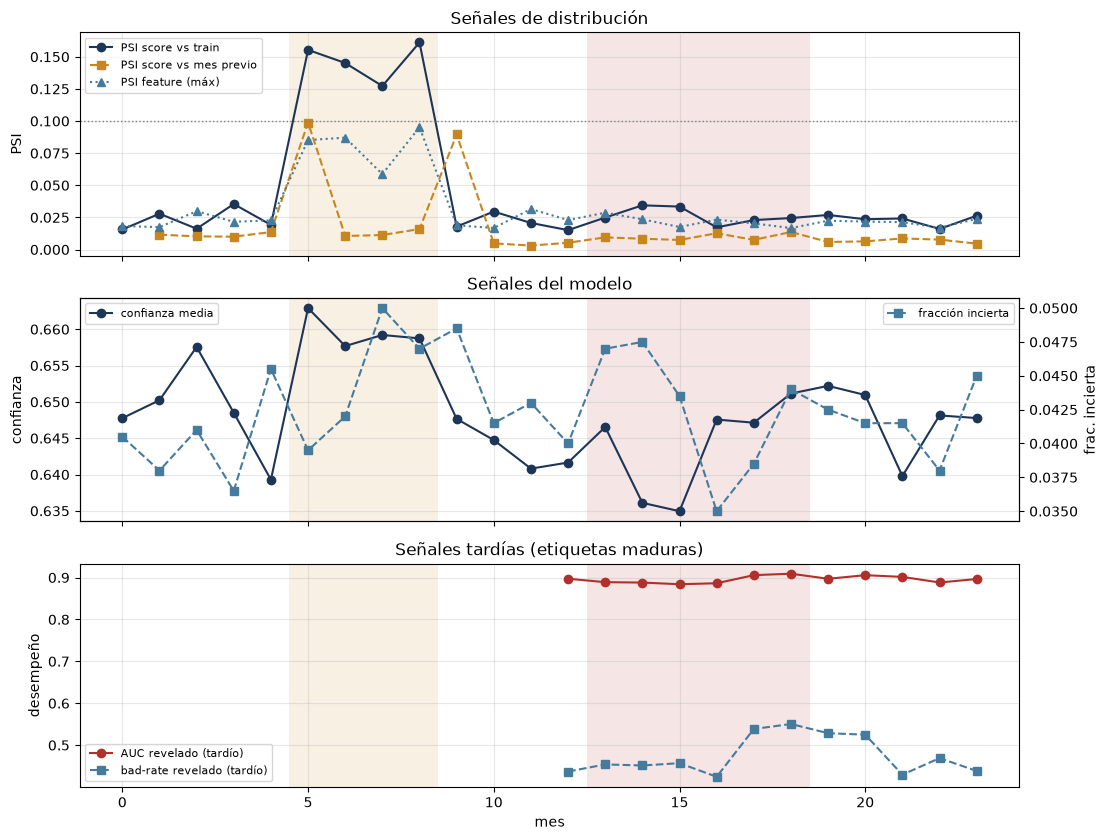

In [6]:
COL = {'covariate_shift': '#C8861E', 'mezcla_poblacional': '#2A7F62', 'concept_drift': '#B0302B'}
def sombrear(ax):
    for t, c in COL.items():
        idx = h.index[h.tipo == t].tolist()
        if idx:
            ax.axvspan(min(idx) - 0.5, max(idx) + 0.5, color=c, alpha=0.12, lw=0)

fig, axs = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)
axs[0].plot(h.periodo, h.psi_score, 'o-', color='#1D3557', label='PSI score vs train')
axs[0].plot(h.periodo, h.psi_score_vs_previo, 's--', color='#C8861E', label='PSI score vs mes previo')
axs[0].plot(h.periodo, h.psi_feat_max, '^:', color='#457B9D', label='PSI feature (máx)')
axs[0].axhline(0.10, color='gray', ls=':', lw=1)
axs[0].set_ylabel('PSI'); axs[0].set_title('Señales de distribución'); axs[0].legend(fontsize=8, loc='upper left')

axs[1].plot(h.periodo, h.confianza_media, 'o-', color='#1D3557', label='confianza media')
a1b = axs[1].twinx(); a1b.plot(h.periodo, h.frac_incierto, 's--', color='#457B9D', label='fracción incierta')
axs[1].set_ylabel('confianza'); a1b.set_ylabel('frac. incierta'); axs[1].set_title('Señales del modelo')
axs[1].legend(fontsize=8, loc='upper left'); a1b.legend(fontsize=8, loc='upper right')

axs[2].plot(h.periodo, h.auc_revelado, 'o-', color='#B0302B', label='AUC revelado (tardío)')
axs[2].plot(h.periodo, h.bad_rate_revelado, 's--', color='#457B9D', label='bad-rate revelado (tardío)')
axs[2].set_ylabel('desempeño'); axs[2].set_xlabel('mes'); axs[2].set_title('Señales tardías (etiquetas maduras)')
axs[2].legend(fontsize=8, loc='lower left')
for ax in axs:
    sombrear(ax); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Drift por variable (`psi_por_feature`)
El reporte guarda el PSI de cada variable monitoreada. Aquí, en un mes de covariate
shift, se ve qué variables de entrada se movieron.

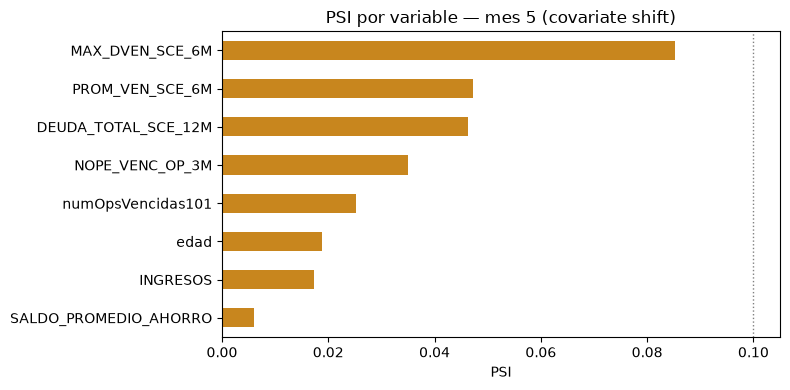

In [7]:
i_cov = next(i for i, t in enumerate(h.tipo) if t == 'covariate_shift')
pf = pd.Series(mon.reportes[i_cov].psi_por_feature).sort_values()
plt.figure(figsize=(8, 4))
pf.plot.barh(color='#C8861E')
plt.axvline(0.10, color='gray', ls=':', lw=1)
plt.title(f'PSI por variable — mes {i_cov} (covariate shift)')
plt.xlabel('PSI'); plt.tight_layout(); plt.show()